# Part 2: Bias Audit - Who Does the Model Hurt?

This notebook audits the baseline toxicity classifier from Part 1 across two cohorts built from the 20,000-row evaluation subset:
- High-black cohort: `black >= 0.5`
- Reference cohort: `black < 0.1 AND white >= 0.5`

It reports TPR, FPR, FNR, Precision, disparate impact (FPR ratio), statistical parity difference, and equal opportunity difference, along with required visualizations.

In [1]:
# Uncomment if needed in your environment.
# !pip install -q transformers datasets accelerate scikit-learn seaborn pandas matplotlib aif360

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments, set_seed

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

d:\Fast\semester_8\responsible_ai\assignment_02\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Using device: cuda


In [2]:
DATA_PATH = os.path.join("dataset", "jigsaw-unintended-bias-train.csv")
CHECKPOINT_DIR = os.path.join("checkpoints", "part1_distilbert_baseline")
MODEL_NAME_FALLBACK = "distilbert-base-uncased"

# Using the selected threshold from Part 1.
THRESHOLD = 0.3

USECOLS = ["comment_text", "toxic", "black", "white"]

In [3]:
df = pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    dtype={
        "comment_text": "string",
        "toxic": "float32",
        "black": "float32",
        "white": "float32",
    },
)

df = df.dropna(subset=["comment_text", "toxic", "black", "white"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

train_df, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    stratify=df["label"],
    random_state=SEED,
)

eval_df = eval_df.reset_index(drop=True)

print(f"Evaluation subset rows: {len(eval_df):,}")
print("Label distribution in eval subset:")
print(eval_df["label"].value_counts(normalize=True).sort_index())

Evaluation subset rows: 20,000
Label distribution in eval subset:
label
0    0.8865
1    0.1135
Name: proportion, dtype: float64


In [4]:
high_black_mask = eval_df["black"] >= 0.5
reference_mask = (eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)

high_black_df = eval_df.loc[high_black_mask].copy()
reference_df = eval_df.loc[reference_mask].copy()

print(f"High-black cohort size: {len(high_black_df):,}")
print(f"Reference cohort size:  {len(reference_df):,}")
print(f"High-black share of eval: {len(high_black_df)/len(eval_df):.4f}")
print(f"Reference share of eval:  {len(reference_df)/len(eval_df):.4f}")

if len(high_black_df) == 0 or len(reference_df) == 0:
    raise ValueError("One cohort is empty. Check data loading and cohort filters.")

High-black cohort size: 710
Reference cohort size:  856
High-black share of eval: 0.0355
Reference share of eval:  0.0428


In [5]:
model_source = CHECKPOINT_DIR if os.path.isdir(CHECKPOINT_DIR) else MODEL_NAME_FALLBACK
print(f"Loading model/tokenizer from: {model_source}")
if model_source == MODEL_NAME_FALLBACK:
    print("Warning: Part 1 checkpoint not found, falling back to base model (audit will be less meaningful).")

tokenizer = AutoTokenizer.from_pretrained(model_source)
model = AutoModelForSequenceClassification.from_pretrained(model_source, num_labels=2)

eval_hf = Dataset.from_pandas(eval_df[["comment_text", "label"]], preserve_index=False)

def tokenize_function(batch):
    return tokenizer(batch["comment_text"], truncation=True, max_length=128)

eval_hf = eval_hf.map(tokenize_function, batched=True, remove_columns=["comment_text"])
eval_hf = eval_hf.rename_column("label", "labels")

inference_args = TrainingArguments(
    output_dir="checkpoints/part2_inference_tmp",
    per_device_eval_batch_size=64 if torch.cuda.is_available() else 8,
    report_to="none",
)

inference_trainer = Trainer(
    model=model,
    args=inference_args,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)

pred_output = inference_trainer.predict(eval_hf)
eval_logits = pred_output.predictions
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1).numpy()[:, 1]
eval_preds = (eval_probs >= THRESHOLD).astype(int)

eval_scored = eval_df.copy()
eval_scored["pred_prob"] = eval_probs
eval_scored["pred_label"] = eval_preds

print(f"Scored rows: {len(eval_scored):,}")
print(f"Using threshold: {THRESHOLD}")

Loading model/tokenizer from: checkpoints\part1_distilbert_baseline


Map: 100%|██████████| 20000/20000 [00:02<00:00, 8098.39 examples/s]


Scored rows: 20,000
Using threshold: 0.3


In [6]:
def safe_div(num, den):
    return float(num / den) if den != 0 else np.nan

def cohort_metrics(df_cohort):
    y_true = df_cohort["label"].to_numpy()
    y_pred = df_cohort["pred_label"].to_numpy()

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = safe_div(tp, tp + fn)
    fpr = safe_div(fp, fp + tn)
    fnr = safe_div(fn, fn + tp)
    precision = safe_div(tp, tp + fp)

    return {
        "size": len(df_cohort),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "TPR": tpr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "PositivePredictionRate": safe_div((y_pred == 1).sum(), len(y_pred)),
    }

high_black_scored = eval_scored.loc[high_black_mask].copy()
reference_scored = eval_scored.loc[reference_mask].copy()

hb_metrics = cohort_metrics(high_black_scored)
ref_metrics = cohort_metrics(reference_scored)

disparate_impact_fpr = safe_div(hb_metrics["FPR"], ref_metrics["FPR"])

metrics_table = pd.DataFrame(
    [
        {"Cohort": "High-black", **hb_metrics},
        {"Cohort": "Reference", **ref_metrics},
    ]
)

display_cols = ["Cohort", "size", "TPR", "FPR", "FNR", "Precision", "PositivePredictionRate", "TP", "FP", "TN", "FN"]
print("Cohort Metrics Summary")
print(metrics_table[display_cols].round(4).to_string(index=False))

print(f"Disparate Impact (FPR High-black / FPR Reference): {disparate_impact_fpr:.4f}")

Cohort Metrics Summary
    Cohort  size    TPR    FPR    FNR  Precision  PositivePredictionRate  TP  FP  TN  FN
High-black   710 0.6977 0.2182 0.3023     0.5814                  0.3634 150 108 387  65
 Reference   856 0.6195 0.1079 0.3805     0.6731                  0.2430 140  68 562  86
Disparate Impact (FPR High-black / FPR Reference): 2.0214


In [7]:
audit_mask = high_black_mask | reference_mask
audit_df = eval_scored.loc[audit_mask, ["label", "pred_label"]].copy()
audit_df["group"] = np.where(eval_scored.loc[audit_mask, "black"] >= 0.5, 1, 0)

true_bld = BinaryLabelDataset(
    df=audit_df[["label", "group"]].copy(),
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=1,
    unfavorable_label=0,
)

pred_bld = BinaryLabelDataset(
    df=audit_df[["pred_label", "group"]].rename(columns={"pred_label": "label"}),
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=1,
    unfavorable_label=0,
)

fairness_metric = ClassificationMetric(
    true_bld,
    pred_bld,
    unprivileged_groups=[{"group": 1}],
    privileged_groups=[{"group": 0}],
)

statistical_parity_difference = fairness_metric.statistical_parity_difference()
equal_opportunity_difference = fairness_metric.equal_opportunity_difference()

print(f"Statistical Parity Difference (high-black - reference): {statistical_parity_difference:.4f}")
print(f"Equal Opportunity Difference (TPR high-black - TPR reference): {equal_opportunity_difference:.4f}")

Statistical Parity Difference (high-black - reference): 0.1204
Equal Opportunity Difference (TPR high-black - TPR reference): 0.0782


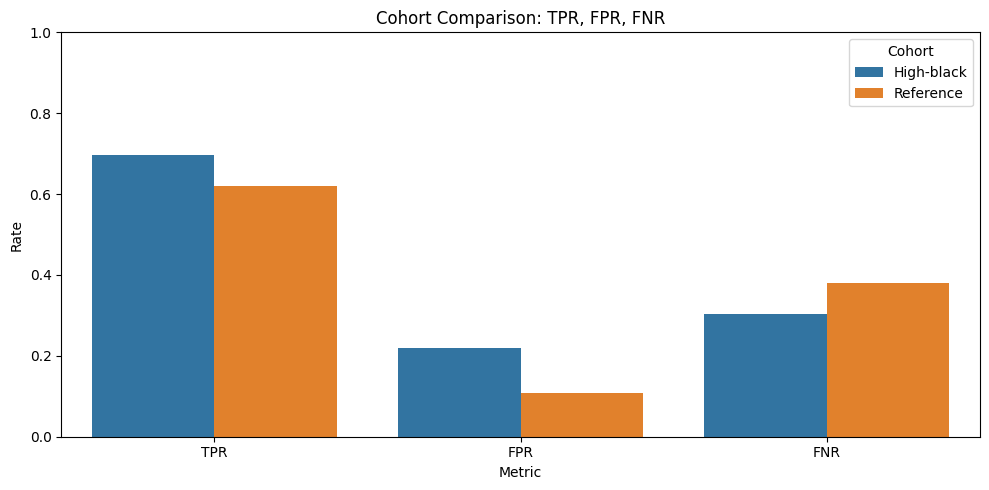

In [8]:
plot_df = metrics_table[["Cohort", "TPR", "FPR", "FNR"]].melt(
    id_vars="Cohort",
    var_name="Metric",
    value_name="Value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Cohort")
plt.ylim(0, 1)
plt.title("Cohort Comparison: TPR, FPR, FNR")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

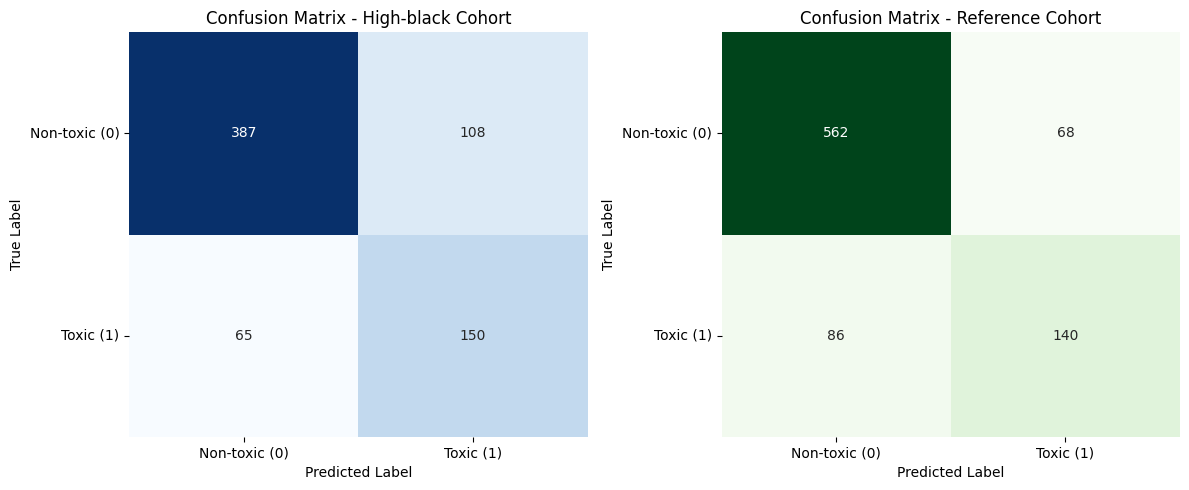

In [9]:
cm_hb = confusion_matrix(high_black_scored["label"], high_black_scored["pred_label"], labels=[0, 1])
cm_ref = confusion_matrix(reference_scored["label"], reference_scored["pred_label"], labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_hb, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - High-black Cohort")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_xticklabels(["Non-toxic (0)", "Toxic (1)"])
axes[0].set_yticklabels(["Non-toxic (0)", "Toxic (1)"], rotation=0)

sns.heatmap(cm_ref, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix - Reference Cohort")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].set_xticklabels(["Non-toxic (0)", "Toxic (1)"])
axes[1].set_yticklabels(["Non-toxic (0)", "Toxic (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [10]:
disparity_deltas = {
    "TPR_gap": hb_metrics["TPR"] - ref_metrics["TPR"],
    "FPR_gap": hb_metrics["FPR"] - ref_metrics["FPR"],
    "FNR_gap": hb_metrics["FNR"] - ref_metrics["FNR"],
    "Precision_gap": hb_metrics["Precision"] - ref_metrics["Precision"],
}
largest_gap_metric = max(disparity_deltas, key=lambda k: abs(disparity_deltas[k]))

print("Largest absolute cohort gap:")
print(f"{largest_gap_metric} = {disparity_deltas[largest_gap_metric]:.4f}")

if disparity_deltas["FPR_gap"] > 0 and disparity_deltas["FNR_gap"] <= 0:
    pattern = "predominantly over-flagging the high-black cohort"
elif disparity_deltas["FNR_gap"] > 0 and disparity_deltas["FPR_gap"] <= 0:
    pattern = "predominantly under-flagging toxic comments in the high-black cohort"
elif disparity_deltas["FPR_gap"] > 0 and disparity_deltas["FNR_gap"] > 0:
    pattern = "showing both over-flagging and under-capture harms on the high-black cohort"
else:
    pattern = "showing mixed or limited directional disparity based on these metrics"

print(f"Interpretation pattern: {pattern}")

Largest absolute cohort gap:
FPR_gap = 0.1102
Interpretation pattern: predominantly over-flagging the high-black cohort


## Key Question Answer

The largest observed disparity is the **false positive rate gap**:
- Largest absolute cohort gap: **FPR_gap = 0.1102**

This indicates the model is **predominantly over-flagging the high-black cohort** compared with the reference cohort.

Interpretation:
- A higher FPR for the high-black cohort means more non-toxic comments from that group are incorrectly labeled as toxic.
- This creates asymmetric moderation harm: legitimate speech is removed or penalized more often for one group, which can reduce user trust and participation.
- Because the dominant gap is in FPR (rather than FNR), the main harm pattern here is wrongful enforcement against benign comments, not primarily missed toxicity.

Real-world consequences:
- For users in the high-black cohort: higher risk of unjust flagging, account friction, and reduced willingness to participate.
- For the platform: perceived unfairness, civil-rights risk, and potential policy/compliance exposure even if overall accuracy appears strong.

Conclusion:
This audit shows that average model quality can mask subgroup harm. In this run, the biggest disparity is over-flagging (FPR inflation) for the high-black cohort, so mitigation should prioritize reducing false positives for that cohort while maintaining acceptable toxicity recall.